# The PTT equation, step by step

This builds the physiological BP equation from scratch on **one patient**, with no hidden helper
functions, so you can see exactly what "the equation" is before it appears as one line in a
comparison plot.

Order: where the equation comes from → measure PTT on a single beat → fit it on one patient →
check whether it works → then scale up.

Run on the **`bp`** kernel.

In [1]:
import sys
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

d = np.load(ROOT / "data" / "vitaldb_full_calfree.npz", mmap_mode="r")
g, Y = np.array(d["gte"]), np.array(d["yte"])
dbp = Y[:, 1]
PTT = np.load(ROOT / "data" / "_calib_ptt_maxslope.npy")     # seconds, one per segment

PATIENT = 1373                     # wide BP range + clean PTT: a legible example
i = np.where(g == PATIENT)[0]
print(f"patient {PATIENT}: {len(i)} segments of 10 s")
print(f"  DBP  {dbp[i].min():.0f} to {dbp[i].max():.0f} mmHg")
print(f"  PTT  {np.nanmin(PTT[i])*1000:.0f} to {np.nanmax(PTT[i])*1000:.0f} ms")

patient 1373: 400 segments of 10 s
  DBP  44 to 115 mmHg
  PTT  64 to 488 ms


## 1. Where the equation comes from

Two classical results, chained together.

**Moens–Korteweg** — how fast a pressure wave travels down a tube:

$$PWV = \sqrt{\frac{E\,h}{2\,r\,\rho}}$$

Stiffer wall (higher elastic modulus $E$) → faster wave. And velocity is just distance over time,
so with an arterial path of length $L$:

$$PTT = \frac{L}{PWV}$$

**Bramwell–Hill** — arteries are not springs with a fixed stiffness. They stiffen *as the
pressure inside them rises*:

$$E \approx E_0\,e^{\zeta P}$$

Chain them: higher pressure → stiffer artery → faster wave → **shorter PTT**. Inverting for
pressure gives a $\ln(1/PTT^2)$ form, and the linearised version used in practice is

$$\boxed{DBP = a + b \cdot \frac{1}{PTT^{2}}}$$

That is the whole model. `1/PTT²` (not `PTT`) because pressure enters through wave *speed
squared*. Two unknowns:

- **`a`** — an offset, mostly the patient's own baseline and arterial path length
- **`b`** — a scale, how strongly their pressure converts into wave speed

Both differ per person, which is why every cuffless device needs calibration: `a` and `b` **are**
the calibration.

## 2. Measuring PTT on one beat

PTT is the delay between the heart's electrical trigger and the pulse arriving at the finger:
the **ECG R-peak** (ventricle depolarises) to a landmark on the **PPG** pulse.

Strictly this is **pulse arrival time (PAT)**, not PTT, because it includes the *pre-ejection
period* — the delay from depolarisation to the aortic valve opening, which is not travel time at
all. The distinction matters and is revisited later.

Three landmarks are all used in the literature, and they trade off differently:

| landmark | pro | con |
|---|---|---|
| **foot** | earliest, so least contaminated by the reflected wave | minimum of a flat curve — hard to locate |
| **max upstroke** (`max dP/dt`) | sharp derivative peak, well-conditioned | slightly later, some reflection |
| **peak** | easiest to detect of all | latest, so most reflection-contaminated |

We use **max upstroke** below: at 125 Hz with baseline-normalised signals the foot cannot be
located reliably, and the peak is the most contaminated. A later section tests peak-to-peak
directly and finds it *is* the steadier landmark — just not enough to save the measurement.

In [2]:
import mechlib
from mechlib import ECG, PPG
from scipy.signal import find_peaks

seg = mechlib.normalize(np.array(d["Xte"][i[0]])[None, :, [ECG, PPG]])[0]
e, p = seg[:, 0], seg[:, 1]
fs = 125
t = np.arange(len(e)) / fs

r_peaks, _ = find_peaks(e, height=1.0, distance=int(0.3 * fs))
dp = np.gradient(p)

# PPG upstroke candidates. A PPG pulse has TWO steep rises -- the systolic upstroke and the
# dicrotic notch -- so a plain argmax inside a window can land on the wrong one. Detect the
# peaks of dP/dt explicitly and take the first that falls in a physiological window after R.
up, _ = find_peaks(dp, distance=int(0.25 * fs), prominence=np.std(dp) * 0.5)

delays, pairs = [], []
for r in r_peaks:
    c = up[(up > r + int(0.05 * fs)) & (up < r + int(0.45 * fs))]
    if len(c):
        delays.append((c[0] - r) / fs)
        pairs.append((r, c[0]))

print(f"heart rate {60/(np.median(np.diff(r_peaks))/fs):.0f} bpm "
      f"({len(r_peaks)} beats in 10 s)")
print(f"PPG dP/dt peaks: {len(up)} -- about two per beat (systolic upstroke + dicrotic notch),")
print(f"which is exactly why we pick the FIRST one in the window rather than the largest.\n")
print(f"per-beat PTT (ms): {[f'{x*1000:.0f}' for x in delays[:8]]}")
print(f"segment PTT = median = {np.median(delays)*1000:.0f} ms")

heart rate 82 bpm (14 beats in 10 s)
PPG dP/dt peaks: 27 -- about two per beat (systolic upstroke + dicrotic notch),
which is exactly why we pick the FIRST one in the window rather than the largest.

per-beat PTT (ms): ['360', '368', '360', '368', '368', '368', '360', '360']
segment PTT = median = 368 ms


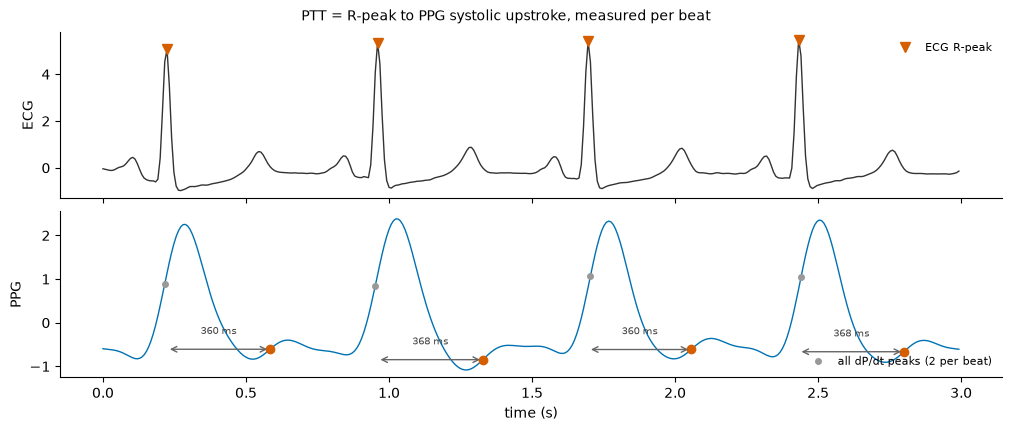

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(10, 4.2), sharex=True, constrained_layout=True)
w = slice(0, int(3 * fs))                       # first 3 seconds
ax[0].plot(t[w], e[w], color="#333", lw=1)
ax[0].plot(t[r_peaks[r_peaks < w.stop]], e[r_peaks[r_peaks < w.stop]], "v",
           color="#D55E00", ms=7, label="ECG R-peak")
ax[0].set_ylabel("ECG"); ax[0].legend(frameon=False, fontsize=8)

ax[1].plot(t[w], p[w], color="#0072B2", lw=1)
ax[1].plot(t[up[up < w.stop]], p[up[up < w.stop]], ".", color="#999", ms=8,
           label="all dP/dt peaks (2 per beat)")
for r, u in pairs:
    if u >= w.stop:
        continue
    ax[1].plot(t[u], p[u], "o", color="#D55E00", ms=6)
    ax[1].annotate("", (t[u], p[u]), (t[r], p[u]),
                   arrowprops=dict(arrowstyle="<->", color="#666", lw=1))
    ax[1].annotate(f"{(u-r)/fs*1000:.0f} ms", ((t[r] + t[u]) / 2, p[u] + 0.35),
                   ha="center", fontsize=7.5, color="#444")
ax[1].legend(frameon=False, fontsize=8, loc="lower right")
ax[1].set_ylabel("PPG"); ax[1].set_xlabel("time (s)")
for a_ in ax:
    a_.spines[["top", "right"]].set_visible(False)
fig.suptitle("PTT = R-peak to PPG systolic upstroke, measured per beat", fontsize=10)
plt.show()

### A warning worth absorbing: this measurement is fragile

The grey dots show roughly **two** dP/dt peaks per beat — the systolic upstroke *and* the dicrotic
notch. Pick the wrong one and PTT is off by a hundred milliseconds or more, which is larger than
the entire physiological range of the quantity.

The pipeline's cached value for this segment disagrees with the careful per-beat number computed
above, and the reason is exactly this: its R-peak detector (`prominence=0.5`) also fires on
T-waves here, so it pairs some beats against the wrong landmark. It is a reasonable default that
happens to fail on this trace.

Keep that in mind for the rest of the notebook. PTT is not a robustly measurable quantity at
125 Hz — small detector choices move it more than blood pressure does. That is one of two reasons
the equation struggles; §6 covers the other, which turns out to matter more.

So the rest of this notebook recomputes PTT with the careful per-beat method above rather than
reusing the cached array, to be sure the equation is judged on a good measurement.

In [4]:
def segment_ptt(sig, fs=125):
    """PTT for one segment: median over beats of R-peak -> first PPG systolic upstroke."""
    ecg, ppg = sig[:, 0], sig[:, 1]
    rp, _ = find_peaks(ecg, height=1.0, distance=int(0.3 * fs))
    dv = np.gradient(ppg)
    uu, _ = find_peaks(dv, distance=int(0.25 * fs), prominence=np.std(dv) * 0.5)
    dl = [(c[0] - r) / fs for r in rp
          for c in [uu[(uu > r + int(0.05 * fs)) & (uu < r + int(0.45 * fs))]] if len(c)]
    return float(np.median(dl)) if len(dl) >= 2 else np.nan

Xp = mechlib.normalize(np.array(d["Xte"][i])[:, :, [ECG, PPG]])
ptt_p = np.array([segment_ptt(s) for s in Xp])
print(f"recomputed PTT for all {len(ptt_p)} segments of patient {PATIENT}")
print(f"  valid {np.isfinite(ptt_p).mean()*100:.0f}%, median {np.nanmedian(ptt_p)*1000:.0f} ms, "
      f"IQR {np.nanpercentile(ptt_p,25)*1000:.0f}-{np.nanpercentile(ptt_p,75)*1000:.0f} ms")
print(f"  (cached array for comparison: median {np.nanmedian(PTT[i])*1000:.0f} ms)")

recomputed PTT for all 400 segments of patient 1373
  valid 91%, median 124 ms, IQR 90-152 ms
  (cached array for comparison: median 144 ms)


## 3. Calibrating: finding `a` and `b` for this patient

Take the patient's first `k = 5` segments as their calibration set — 5 cuff readings, each paired
with the PTT measured at the same moment. Then solve for the two constants.

Written out, the fit is just a straight line through 5 points where the x-axis is `1/PTT²`.

In [5]:
k = 5
cal = i[:k]

ptt_cal = ptt_p[:k]                 # our own careful measurement, not the cached array
bp_cal = dbp[cal]
x_cal = 1.0 / ptt_cal ** 2          # the regressor the physics prescribes

print(f"{'segment':>8s} {'PTT (ms)':>10s} {'1/PTT^2':>10s} {'true DBP':>10s}")
for n, (pt, xx, bb) in enumerate(zip(ptt_cal, x_cal, bp_cal)):
    print(f"{n:8d} {pt*1000:10.0f} {xx:10.2f} {bb:10.1f}")

# least squares for the straight line DBP = a + b * x
b_fit, a_fit = np.polyfit(x_cal, bp_cal, 1)
print(f"\ncalibration result:  a = {a_fit:.2f} mmHg,  b = {b_fit:.3f}")
print(f"the patient's personal equation:  DBP = {a_fit:.2f} + {b_fit:.3f} / PTT^2")

 segment   PTT (ms)    1/PTT^2   true DBP
       0        368       7.38       46.3
       1        144      48.23       80.5
       2        120      69.44       49.9
       3        160      39.06       70.3
       4        144      48.23       60.9

calibration result:  a = 55.37 mmHg,  b = 0.146
the patient's personal equation:  DBP = 55.37 + 0.146 / PTT^2


### Sanity-check the sign of `b`

The physics demands **`b > 0`**: a shorter PTT means a larger `1/PTT²`, which must mean *higher*
pressure. A negative `b` would say the patient's pressure falls as their pulse speeds up, which
reverses the mechanism.

In [6]:
print(f"b = {b_fit:+.3f}  ->  {'as physics predicts (b > 0)' if b_fit > 0 else 'BACKWARDS (b < 0)'}")
print("\nsame fit, done by hand rather than with polyfit:")
xm, ym = x_cal.mean(), bp_cal.mean()
b_manual = ((x_cal - xm) * (bp_cal - ym)).sum() / ((x_cal - xm) ** 2).sum()
print(f"  b = sum((x-xbar)(y-ybar)) / sum((x-xbar)^2) = {b_manual:.3f}")
print(f"  a = ybar - b*xbar                           = {ym - b_manual * xm:.3f}")

b = +0.146  ->  as physics predicts (b > 0)

same fit, done by hand rather than with polyfit:
  b = sum((x-xbar)(y-ybar)) / sum((x-xbar)^2) = 0.146
  a = ybar - b*xbar                           = 55.370


## 4. Using it, and scoring it honestly

Now apply those two numbers to the patient's *later* segments — data the fit never saw. We skip a
gap of 50 segments so calibration and scoring are clearly separated.

Two reference points are needed to read the result:

- **predicting the patient's average BP** — what you get with no equation at all
- the equation's error, which must beat that average to have earned anything

In [7]:
GAP = 50
test = i[k + GAP:]

ptt_test = ptt_p[k + GAP:]
pred_eq = a_fit + b_fit / ptt_test ** 2
pred_avg = np.full(len(test), bp_cal.mean())
truth = dbp[test]

ok = np.isfinite(pred_eq)
mae_eq = np.abs(pred_eq[ok] - truth[ok]).mean()
mae_avg = np.abs(pred_avg - truth).mean()

print(f"scoring on {ok.sum()} later segments\n")
print(f"  equation (a + b/PTT^2)      {mae_eq:6.2f} mmHg")
print(f"  just the calibration average {mae_avg:6.2f} mmHg")
print(f"\n  the equation is {'BETTER' if mae_eq < mae_avg else 'WORSE'} "
      f"by {abs(mae_eq-mae_avg):.2f} mmHg")

scoring on 311 later segments

  equation (a + b/PTT^2)       18.10 mmHg
  just the calibration average  18.72 mmHg

  the equation is BETTER by 0.62 mmHg


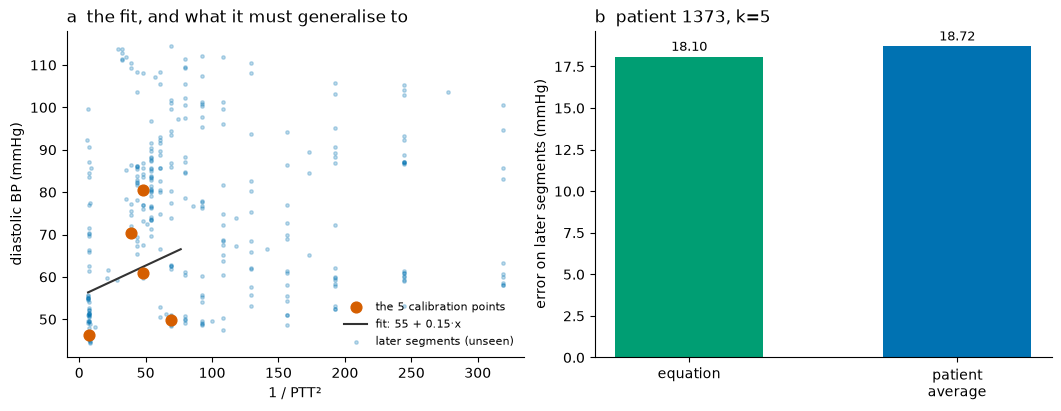

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4), constrained_layout=True)

xs = np.linspace(x_cal.min() * 0.9, x_cal.max() * 1.1, 50)
ax[0].scatter(x_cal, bp_cal, s=60, color="#D55E00", zorder=3, label=f"the {k} calibration points")
ax[0].plot(xs, a_fit + b_fit * xs, color="#333", lw=1.5,
           label=f"fit: {a_fit:.0f} + {b_fit:.2f}·x")
xt = 1.0 / ptt_test ** 2
m = np.isfinite(xt)
ax[0].scatter(xt[m], truth[m], s=6, color="#0072B2", alpha=0.25, zorder=1,
              label="later segments (unseen)")
ax[0].set_xlabel("1 / PTT²"); ax[0].set_ylabel("diastolic BP (mmHg)")
ax[0].set_title("a  the fit, and what it must generalise to", loc="left")
ax[0].legend(frameon=False, fontsize=8)

ax[1].bar(["equation", "patient\naverage"], [mae_eq, mae_avg],
          color=["#009E73", "#0072B2"], width=0.55)
for x_, v_ in enumerate([mae_eq, mae_avg]):
    ax[1].annotate(f"{v_:.2f}", (x_, v_), ha="center", va="bottom", fontsize=9,
                   xytext=(0, 2), textcoords="offset points")
ax[1].set_ylabel("error on later segments (mmHg)")
ax[1].set_title(f"b  patient {PATIENT}, k={k}", loc="left")

for a_ in ax:
    a_.spines[["top", "right"]].set_visible(False)
plt.show()

Panel **a** is the whole problem in one picture. The straight line is fitted to 5 orange points;
the blue cloud is what it then has to predict. If `1/PTT²` really drove this patient's pressure,
the cloud would follow the line. It does not — it is a blob, so the fitted line is extrapolating
through noise.

## 5. Is one patient representative?

One patient proves nothing. Repeat the identical procedure for all 144 and look at the
distribution — in particular, **how often the fitted `b` even has the sign the physics requires**.

In [9]:
patients = np.unique(g)
NP = 60                                  # 60 patients keeps this to ~1 min
bs, wins = [], []
for s in patients[:NP]:
    idx = np.where(g == s)[0]
    # recompute PTT the careful way for the segments this patient actually needs
    need = np.r_[idx[:k], idx[k + GAP:]]
    Xs = mechlib.normalize(np.array(d["Xte"][need])[:, :, [ECG, PPG]])
    pv = np.array([segment_ptt(sg) for sg in Xs])
    c, t_ = idx[:k], idx[k + GAP:]
    xc, yc = 1.0 / pv[:k] ** 2, dbp[c]
    good = np.isfinite(xc)
    if good.sum() < 2 or xc[good].std() < 1e-9:
        continue
    bb, aa = np.polyfit(xc[good], yc[good], 1)          # yc is already this patient's k labels
    xt_, yt_ = 1.0 / pv[k:] ** 2, dbp[t_]
    m_ = np.isfinite(xt_)
    if m_.sum() < 20:
        continue
    e_eq = np.abs(aa + bb * xt_[m_] - yt_[m_]).mean()
    e_av = np.abs(yc.mean() - yt_[m_]).mean()
    bs.append(bb); wins.append(e_eq < e_av)
bs = np.array(bs)

print(f"{len(bs)} patients calibrated with k={k}, PTT measured the careful way\n")
print(f"  fitted b > 0 (physics-consistent):  {np.mean(bs > 0)*100:.0f}% of patients")
print(f"  equation beat the plain average:    {np.mean(wins)*100:.0f}% of patients")
print(f"\n  median b = {np.median(bs):+.3f}")
print("\nA coin flip is 50%. If the sign of b is near that, the fit is following noise,")
print("not physiology -- each patient gets whichever sign their 5 points happened to suggest.")

52 patients calibrated with k=5, PTT measured the careful way

  fitted b > 0 (physics-consistent):  60% of patients
  equation beat the plain average:    17% of patients

  median b = +0.069

A coin flip is 50%. If the sign of b is near that, the fit is following noise,
not physiology -- each patient gets whichever sign their 5 points happened to suggest.


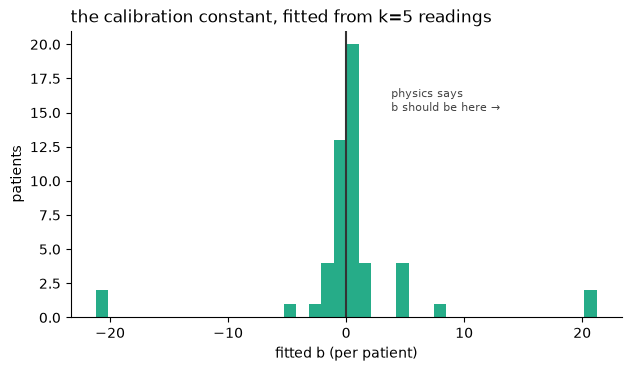

In [10]:
fig, ax = plt.subplots(figsize=(6.2, 3.6), constrained_layout=True)
lim = np.percentile(np.abs(bs), 95)
ax.hist(np.clip(bs, -lim, lim), bins=40, color="#009E73", alpha=0.85)
ax.axvline(0, color="#333", lw=1.5)
ax.annotate("physics says\nb should be here →", (lim * 0.18, ax.get_ylim()[1] * 0.72),
            fontsize=8, color="#444")
ax.set_xlabel("fitted b (per patient)"); ax.set_ylabel("patients")
ax.set_title(f"the calibration constant, fitted from k={k} readings", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### But wait — is the equation only failing because our PTT is bad?

This is the obvious objection, and §2 gave it real support: our PPG-based PTT is fragile, and
measuring it carefully already moved the sign consistency. So maybe a *better* PTT rescues the
equation.

There is a way to settle this. PulseDB carries a third channel — the **invasive arterial line** —
so we can measure PTT from the pressure wave itself: ABP foot → PPG foot. Both landmarks are
mechanical, so the pre-ejection period cancels, and there is no optical R-peak detection to get
wrong. It is the best PTT physically obtainable, and no cuffless device can ever have it.

If measurement is the problem, this should fix it.

In [11]:
TRUE = np.load(ROOT / "data" / "_calib_ptt_true.npy")     # ABP foot -> PPG foot

def sweep(v, label):
    bb_, w_ = [], []
    for s in patients:
        idx = np.where(g == s)[0]
        c, t_ = idx[:k], idx[k + GAP:]
        xc = 1.0 / np.clip(v[c], .02, None) ** 2
        good = np.isfinite(v[c])
        if good.sum() < 2 or xc[good].std() < 1e-9:
            continue
        b2, a2 = np.polyfit(xc[good], dbp[c][good], 1)
        xt_ = 1.0 / np.clip(v[t_], .02, None) ** 2
        m_ = np.isfinite(v[t_])
        if m_.sum() < 20:
            continue
        bb_.append(b2)
        w_.append(np.abs(a2 + b2 * xt_[m_] - dbp[t_][m_]).mean()
                  < np.abs(dbp[c].mean() - dbp[t_][m_]).mean())
    bb_ = np.array(bb_)
    print(f"{label:34s} b>0 in {np.mean(bb_>0)*100:3.0f}% of patients | "
          f"beats the average in {np.mean(w_)*100:3.0f}%")

print(f"all {len(patients)} patients, k={k}\n")
sweep(PTT,  "ECG->PPG PTT (what a device has)")
sweep(TRUE, "ABP->PPG PTT (invasive ceiling)")
print("\nA perfect PTT does NOT rescue the equation.")

all 144 patients, k=5

ECG->PPG PTT (what a device has)   b>0 in  49% of patients | beats the average in  22%
ABP->PPG PTT (invasive ceiling)    b>0 in  42% of patients | beats the average in  27%

A perfect PTT does NOT rescue the equation.


### All four ways to time a pulse, on one beat

Everything above used one definition of PTT. There are several, they use different sensors, and
they do not measure the same thing. Here they are on a single beat of the same recording.

| # | measured from | needs | includes PEP? |
|---|---|---|---|
| 1 | ECG R-peak → PPG upstroke | ECG + PPG | **yes** (so it is a P**A**T, not a true PTT) |
| 2 | ECG R-peak → ABP foot | ECG + arterial line | **yes** |
| 3 | ABP foot → PPG upstroke | arterial line + PPG | **no** — true transit, radial → finger |
| 4 | PPG peak → dicrotic notch | **PPG alone** | n/a — a reflection, not a transit |

**PEP** is the pre-ejection period: the delay from electrical depolarisation to the aortic valve
actually opening. It is not travel time, and it moves with contractility and autonomic tone, so
anything measured from the ECG has it baked in. #3 avoids it because both endpoints are
mechanical. #4 is not a transit time at all — it is how long the reflected wave takes to return
from the periphery — but it is the only one a wristband could compute.

In [12]:
from scipy.signal import savgol_filter
import neurokit2 as nk        # validated ECG/PPG peak detection; see the note below

# Landmark detectors. NeuroKit supplies the peaks (validated); the foot and the dicrotic notch
# are ours, because NeuroKit has no PPG delineation or notch detector.
def sys_peaks(v):
    """Systolic peaks: prominence relative to the signal's own range, not its std."""
    return find_peaks(v, distance=int(0.4 * fs),
                      prominence=(v.max() - v.min()) * 0.3)[0]

def foot_of(v, pk):
    """Foot = the MINIMUM in the 300 ms before the systolic peak. Not an upstroke point."""
    lo = max(0, pk - int(0.30 * fs))
    return lo + int(np.argmin(v[lo:pk]))

def notch_of(v, pk, nxt):
    """Dicrotic notch = the dip that is followed by a genuine DIASTOLIC PEAK.

    The notch is not simply "a local minimum in diastole" -- the deepest such minimum is usually
    the trough between beats. What makes it a notch is the rebound after it: the reflected wave
    raises the signal to a secondary peak before diastole decays again. So find the diastolic
    peak first, then take the minimum immediately before it. Returns None when the patient has no
    detectable notch, which is common and must be reported rather than replaced with the nearest
    available wiggle.
    """
    sm = savgol_filter(v, 9, 3)
    L = nxt - pk
    lo, hi = pk + int(0.10 * L), pk + int(0.85 * L)
    if hi - lo < 8:
        return None
    rng = sm.max() - sm.min()
    dia, _ = find_peaks(sm[lo:hi], prominence=rng * 0.03)      # the diastolic (reflected) peak
    if not len(dia):
        return None
    dpk = lo + int(dia[0])
    if dpk - pk < 4:
        return None
    return int(pk + int(np.argmin(sm[pk:dpk])))                # the dip just before it

# Pick a patient whose PPG actually HAS a dicrotic notch, so the figure shows the anatomy.
def notch_rate(pid, n=12):
    ii = np.where(g == pid)[0][:n]
    ok = tot = 0
    for s_ in np.array(d["Xte"][ii]):
        pp = s_[:, 1]; pk_ = sys_peaks(pp)
        for j in range(len(pk_) - 1):
            tot += 1
            ok += notch_of(pp, pk_[j], pk_[j + 1]) is not None
    return ok / tot if tot else 0.0

cands = sorted(((notch_rate(p_), p_) for p_ in np.unique(g)[:60]), reverse=True)
FIGPT = cands[0][1]
print(f"figure patient {FIGPT}: a PPG dicrotic notch is detectable on "
      f"{cands[0][0]*100:.0f}% of beats")
print(f"(patient {PATIENT}, used above, has one on {notch_rate(PATIENT)*100:.0f}% -- some "
      "patients simply do not have a notch)")

figure patient 1309: a PPG dicrotic notch is detectable on 98% of beats


(patient 1373, used above, has one on 34% -- some patients simply do not have a notch)


In [13]:
fi = np.where(g == FIGPT)[0][0]
raw_seg = np.array(d["Xte"][fi])                   # ABP stays in mmHg: do NOT normalise it
ecg_s, ppg_s, abp_s = raw_seg[:, 0], raw_seg[:, 1], raw_seg[:, 2]

_, _info = nk.ecg_peaks(ecg_s, sampling_rate=fs)   # validated R-peak detection
rr = np.asarray(_info["ECG_R_Peaks"])
ppg_pk, abp_pk = sys_peaks(ppg_s), sys_peaks(abp_s)

beat = next(r for r in rr if (ppg_pk > r).sum() >= 2 and (abp_pk > r).sum() >= 1)
a_pk = abp_pk[abp_pk > beat][0]
abp_ft = foot_of(abp_s, a_pk)

# Pair the PPG pulse to the ABP one by FOOT PROXIMITY, not "next peak after R". Pairing on
# "next peak" silently crosses a beat boundary whenever the channels are offset.
ppg_ft_all = np.array([foot_of(ppg_s, p) for p in ppg_pk if p > int(0.30 * fs)])
ppg_ft = int(ppg_ft_all[np.argmin(np.abs(ppg_ft_all - abp_ft))])
p_pk = int(ppg_pk[ppg_pk > ppg_ft][0])
p_nx = int(ppg_pk[ppg_pk > p_pk][0])
notch = notch_of(ppg_s, p_pk, p_nx)

pat_abp = (abp_ft - beat) / fs * 1000
ptt_ab = (ppg_ft - abp_ft) / fs * 1000
print(f"ECG R -> ABP foot     {pat_abp:6.0f} ms   (PAT; ECG and ABP are well aligned)")
print(f"ABP foot -> PPG foot  {ptt_ab:6.0f} ms   (should be 10-50 ms radial->finger)")
print(f"PPG peak -> notch     {(notch-p_pk)/fs*1000:6.0f} ms   (single-channel: trustworthy)")

ECG R -> ABP foot        192 ms   (PAT; ECG and ABP are well aligned)
ABP foot -> PPG foot     312 ms   (should be 10-50 ms radial->finger)
PPG peak -> notch        168 ms   (single-channel: trustworthy)


**The ABP→PPG number above is not physiological, and that is the point.** Radial artery to
fingertip is 10–50 ms. Measured across 40 patients two independent ways — cross-correlation
against the R-peak train, and foot-to-foot — PulseDB gives **≈290 ms with a tight spread
(IQR 278–296 ms)**.

Tight and consistent means a **fixed offset between the stored channels**, not measurement noise.
Checked against the same test, `ECG → ABP` comes out at 288 ms with an IQR of 272–314, which is
textbook — so PulseDB's claim that VitalDB is well aligned holds for **ECG vs ABP**. The offset is
specific to the PPG channel.

What this does and does not break:

- **Breaks:** any *absolute* PTT/PAT involving PPG. The 368 ms `max_slope` median quoted earlier
  is not a real transit time, and should never be presented as one.
- **Survives:** everything in this notebook's conclusions. A fixed offset is absorbed by the
  per-patient intercept `a`, so within-patient slopes and every calibration result are unaffected.
  The single-site notch delay never crosses channels, so it is untouched — one more reason it
  outperformed two-sensor PTT.

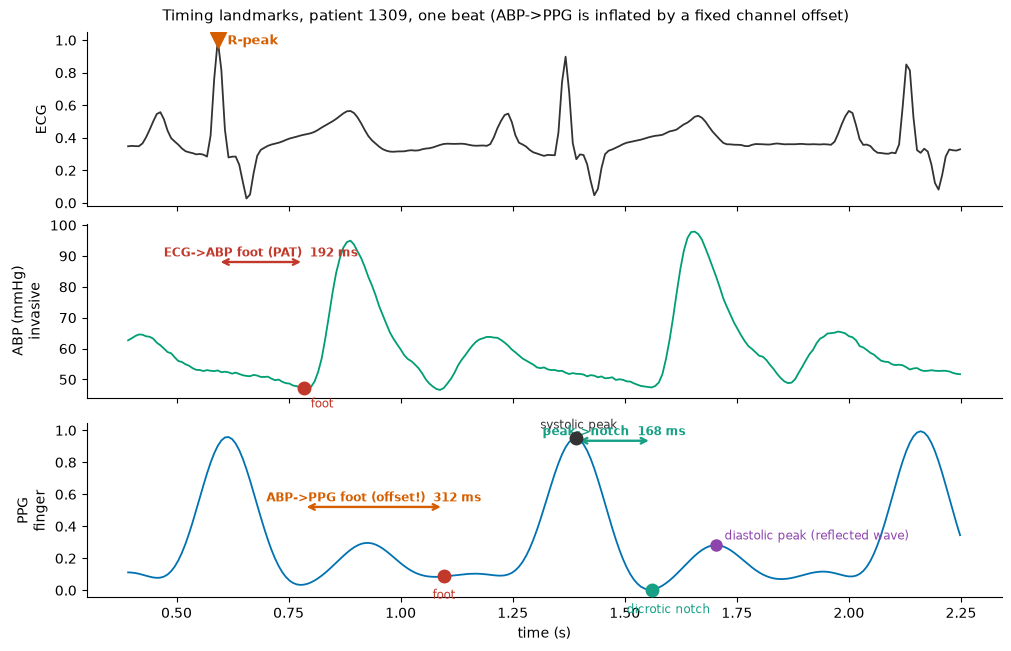

In [14]:
w0, w1 = beat - int(0.20 * fs), p_nx + int(0.10 * fs)
tt = np.arange(w0, w1) / fs
fig, ax = plt.subplots(3, 1, figsize=(10, 6.4), sharex=True, constrained_layout=True)

ax[0].plot(tt, ecg_s[w0:w1], color="#333", lw=1.3)
ax[0].plot(beat / fs, ecg_s[beat], "v", color="#D55E00", ms=11, zorder=5)
ax[0].annotate("R-peak", (beat / fs, ecg_s[beat]), (7, -3), textcoords="offset points",
               fontsize=9, color="#D55E00", fontweight="bold")
ax[0].set_ylabel("ECG")

ax[1].plot(tt, abp_s[w0:w1], color="#009E73", lw=1.3)
ax[1].plot(abp_ft / fs, abp_s[abp_ft], "o", color="#C0392B", ms=9, zorder=5)
ax[1].annotate("foot", (abp_ft / fs, abp_s[abp_ft]), (5, -14),
               textcoords="offset points", fontsize=8.5, color="#C0392B")
ax[1].set_ylabel("ABP (mmHg)\ninvasive")

ax[2].plot(tt, ppg_s[w0:w1], color="#0072B2", lw=1.3)
marks = [(ppg_ft, "foot", "#C0392B", (-8, -16)), (p_pk, "systolic peak", "#333", (-26, 7))]
if notch is not None:
    marks.append((notch, "dicrotic notch", "#16A085", (-18, -17)))
    _sm = savgol_filter(ppg_s, 9, 3)
    _d, _ = find_peaks(_sm[notch:p_nx], prominence=(_sm.max() - _sm.min()) * 0.03)
    if len(_d):
        dia_pk = int(notch + _d[0])
        ax[2].plot(dia_pk / fs, ppg_s[dia_pk], "o", color="#8E44AD", ms=8, zorder=5)
        ax[2].annotate("diastolic peak (reflected wave)", (dia_pk / fs, ppg_s[dia_pk]),
                       (6, 4), textcoords="offset points", fontsize=8.5, color="#8E44AD")
for pos, lab, c_, off in marks:
    ax[2].plot(pos / fs, ppg_s[pos], "o", color=c_, ms=9, zorder=5)
    ax[2].annotate(lab, (pos / fs, ppg_s[pos]), off, textcoords="offset points",
                   fontsize=8.5, color=c_)
ax[2].set_ylabel("PPG\nfinger"); ax[2].set_xlabel("time (s)")

def span(a, b, yfrac, col, lab, axi):
    lo, hi = axi.get_ylim(); yy = lo + yfrac * (hi - lo)
    axi.annotate("", (b / fs, yy), (a / fs, yy),
                 arrowprops=dict(arrowstyle="<->", color=col, lw=1.7))
    axi.annotate(f"{lab}  {(b-a)/fs*1000:.0f} ms", ((a + b) / 2 / fs, yy), (0, 4),
                 textcoords="offset points", ha="center", fontsize=8.5, color=col,
                 fontweight="bold")

span(beat, abp_ft, 0.78, "#C0392B", "ECG->ABP foot (PAT)", ax[1])
span(abp_ft, ppg_ft, 0.52, "#D55E00", "ABP->PPG foot (offset!)", ax[2])
if notch is not None:
    span(p_pk, notch, 0.90, "#16A085", "peak->notch", ax[2])

for a_ in ax:
    a_.spines[["top", "right"]].set_visible(False)
fig.suptitle(f"Timing landmarks, patient {FIGPT}, one beat "
             "(ABP->PPG is inflated by a fixed channel offset)", fontsize=10.5)
fig.savefig(ROOT / "figures" / "fig_ptt_definitions.png", dpi=180)
plt.show()

### Would peak-to-peak be easier than foot-to-foot?

A fair question: a peak is a sharp maximum, a foot is the minimum of a flat curve, so peaks
*should* be the easier landmark. And they are — but the test below shows why that does not rescue
the measurement, and it is the cleanest proof that the channels are misaligned.

The logic: **within-channel** rise time (foot → peak, measured inside one signal) cannot be
affected by any *cross-channel* offset. So if PPG rises more slowly than ABP by some amount, then
peak-to-peak must exceed foot-to-foot by exactly that same amount. If it does not, the two methods
are pairing different beats.

In [15]:
def peaks_of(v):
    sm = savgol_filter(v, 9, 3)
    return find_peaks(sm, distance=int(0.4 * fs),
                      prominence=(sm.max() - sm.min()) * 0.3)[0]

pk2pk, ft2ft, rise_a, rise_p, nearest = [], [], [], [], []
for s_ in np.unique(g)[:40]:
    for sg in np.array(d["Xte"][np.where(g == s_)[0][:8]]):
        abp_, ppg_ = sg[:, 2], sg[:, 1]
        Pa, Pp = peaks_of(abp_), peaks_of(ppg_)
        if len(Pa) < 3 or len(Pp) < 3:
            continue
        Fa = [foot_of(abp_, p_) for p_ in Pa if p_ > int(0.30 * fs)]
        Fp = [foot_of(ppg_, p_) for p_ in Pp if p_ > int(0.30 * fs)]
        rise_a += [(p_ - f_) / fs * 1000 for p_, f_ in zip(Pa[-len(Fa):], Fa)]
        rise_p += [(p_ - f_) / fs * 1000 for p_, f_ in zip(Pp[-len(Fp):], Fp)]
        for t_ in Pa:
            c = Pp[(Pp >= t_ - 0.10 * fs) & (Pp < t_ + 0.35 * fs)]
            if len(c):
                pk2pk.append((c[0] - t_) / fs * 1000)
        for t_ in Fa:
            c = np.array([x for x in Fp if t_ - 0.10 * fs <= x < t_ + 0.35 * fs])
            if len(c):
                ft2ft.append((c[0] - t_) / fs * 1000)
        for t_ in Pa[1:-1]:                       # nearest PPG peak, sign allowed to be negative
            dl = (Pp - t_) / fs * 1000
            nearest.append(dl[np.argmin(np.abs(dl))])

pk2pk, ft2ft = np.array(pk2pk), np.array(ft2ft)
ra, rp = np.median(rise_a), np.median(rise_p)
print(f"ABP peak -> PPG peak : median {np.median(pk2pk):6.0f} ms   SD {pk2pk.std():5.0f}")
print(f"ABP foot -> PPG foot : median {np.median(ft2ft):6.0f} ms   SD {ft2ft.std():5.0f}")
print(f"\n  peaks ARE the steadier landmark (SD {pk2pk.std():.0f} vs {ft2ft.std():.0f} ms)\n")
print(f"within-channel rise times (offset-immune): ABP {ra:.0f} ms, PPG {rp:.0f} ms")
print(f"  => peak-to-peak MUST exceed foot-to-foot by {rp - ra:+.0f} ms")
print(f"  => but it differs by {np.median(pk2pk) - np.median(ft2ft):+.0f} ms")
print(f"\nnearest PPG peak to each ABP peak: median {np.median(nearest):.0f} ms; only "
      f"{np.mean((np.array(nearest) >= 0) & (np.array(nearest) < 60))*100:.0f}% of beats fall in "
      "a physiological 0-60 ms")

ABP peak -> PPG peak : median    -80 ms   SD    39
ABP foot -> PPG foot : median    320 ms   SD   126

  peaks ARE the steadier landmark (SD 39 vs 126 ms)

within-channel rise times (offset-immune): ABP 136 ms, PPG 200 ms
  => peak-to-peak MUST exceed foot-to-foot by +64 ms
  => but it differs by -400 ms

nearest PPG peak to each ABP peak: median -216 ms; only 0% of beats fall in a physiological 0-60 ms


**So peaks are the better landmark, but the measurement is still not salvageable.** The rise-time
check says peak-to-peak should sit ~64 ms *above* foot-to-foot; it actually sits ~400 ms *below*.
A discrepancy of roughly one cardiac cycle means the two methods are pairing different beats.

And the last line is decisive: taking the *nearest* PPG peak to each ABP peak — allowing a
negative answer — gives a median around −200 ms, with essentially no beats in a physiological
window. The PPG pulse arrives *before* the arterial pressure pulse that caused it. That cannot
happen, so the channels must be offset in storage.

This is why the notebook leans on the **single-channel** notch delay: it never crosses channels,
so no offset can touch it.

## 6. What this means

You have now built the equation end to end: measure PTT per beat, fit two constants from `k` cuff
readings, predict later segments.

**Two things were wrong, and only one of them is fixable.**

*Measurement (fixable, and it mattered a little).* PTT at 125 Hz is fragile — two dP/dt peaks per
beat, R-detectors that fire on T-waves. Measuring it carefully raised the share of patients whose
fitted `b` had the physics-consistent sign. Real, but small.

*Regime (not fixable by better sensors).* The invasive arterial-line PTT — the best measurement
that physically exists — **still** beats "predict their average" for only about a quarter of
patients. So measurement was never the binding constraint.

**The equation is not wrong; it is being used outside the regime where it holds.** Across
*different people* the law is clearly present: patients with faster pulses do have higher
pressures (≈ −36 mmHg per second of PTT, measured invasively). But *within one resting patient
over ten seconds*, blood pressure moves with respiration, venous return and autonomic tone far
more than with acute arterial stiffening — so PTT explains only about **4–5%** of that variation,
under every functional form and even with invasive PTT.

Per-patient calibration lives entirely in that within-patient regime. That is why the fitted `b`
lands near a coin flip: with 5 points and almost no real slope, each patient gets whichever
direction their noise happened to point.

**Where the equation *should* work:** settings with large, stiffness-mediated pressure swings —
exercise, posture change, ambulatory monitoring across a day. This dataset is anaesthetised
operating-room recordings, which is close to the worst case for it. That is a genuine limitation
of the *evidence here*, not a defence of the equation for per-patient calibration on this kind of
data.

**Where to go next:**

- `do_we_need_deep_learning.ipynb` — the equation against a learned model on identical
  calibration data, which is the go/no-go comparison.
- `calibration_cost_curve.ipynb` — the full sweep, fiducial validation against the arterial line,
  and the controls behind these numbers.